In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs


# ============================================================
# Settings
# ============================================================

MASK_FILE = "/nird/datalake/NS11071K/users/yongyub/RECCAP2/RECCAP2_region_masks_all_v20221025.nc"

MASK_VARS = [
    "open_ocean",
    "atlantic",
    "pacific",
    "indian",
    "southern",
    "arctic",
]


# ============================================================
# Helper functions
# ============================================================

def parse_region_names(da):
    """
    Parse region_name attribute:
    '1.Atlantic, 2.Pacific, ...'
    """
    attr = da.attrs.get("region_name", "")
    out = {}

    if not attr:
        return out

    for item in attr.split(","):
        item = item.strip()
        if "." not in item:
            continue

        key, name = item.split(".", 1)

        try:
            out[int(key.strip())] = name.strip()
        except ValueError:
            pass

    return out


def get_region_ids(da):
    vals = np.unique(da.values)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return sorted(vals.astype(int))


def weighted_centroid(lon, lat, mask):
    """
    Area-weighted centroid for label position.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    if np.nansum(weights) == 0:
        return np.nan, np.nan

    # Circular mean longitude
    lon_rad = np.deg2rad(lon2d)
    x = np.nansum(weights * np.cos(lon_rad)) / np.nansum(weights)
    y = np.nansum(weights * np.sin(lon_rad)) / np.nansum(weights)

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / np.nansum(weights)

    return lon_c, lat_c


def lon_to_180(lon):
    return ((lon + 180) % 360) - 180


def add_basic_map(ax, ds):
    """
    Add simple coast-like contour using seamask.
    This avoids Cartopy coastline download problems on HPC.
    """
    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=9)

    if "seamask" in ds:
        ax.contour(
            ds["lon"],
            ds["lat"],
            ds["seamask"],
            levels=[0.5],
            colors="k",
            linewidths=0.4,
            transform=ccrs.PlateCarree(),
        )


def plot_reccap2_mask(ds, varname):
    da = ds[varname]

    lon = ds["lon"].values
    lat = ds["lat"].values

    region_ids = get_region_ids(da)
    region_names = parse_region_names(da)

    plot_da = da.where(da > 0)

    cmap = plt.get_cmap("tab20", len(region_ids)).copy()
    cmap.set_bad((1, 1, 1, 0))

    bounds = np.arange(min(region_ids) - 0.5, max(region_ids) + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    fig = plt.figure(figsize=(12, 5.5))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    im = ax.pcolormesh(
        lon,
        lat,
        plot_da,
        cmap=cmap,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    add_basic_map(ax, ds)

    ax.set_title(f"RECCAP2 mask: {varname}", fontsize=15)

    # Add region number labels
    for rid in region_ids:
        mask = da.values == rid
        lon_c, lat_c = weighted_centroid(lon, lat, mask)

        if np.isfinite(lon_c) and np.isfinite(lat_c):
            ax.text(
                lon_to_180(lon_c),
                lat_c,
                str(rid),
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    boxstyle="round,pad=0.15",
                ),
            )

    cbar = plt.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.06,
        shrink=0.95,
        ticks=region_ids,
    )

    labels = [
        f"{rid}: {region_names.get(rid, f'{varname} region {rid}')}"
        for rid in region_ids
    ]
    cbar.ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)

    plt.tight_layout()
    plt.show()

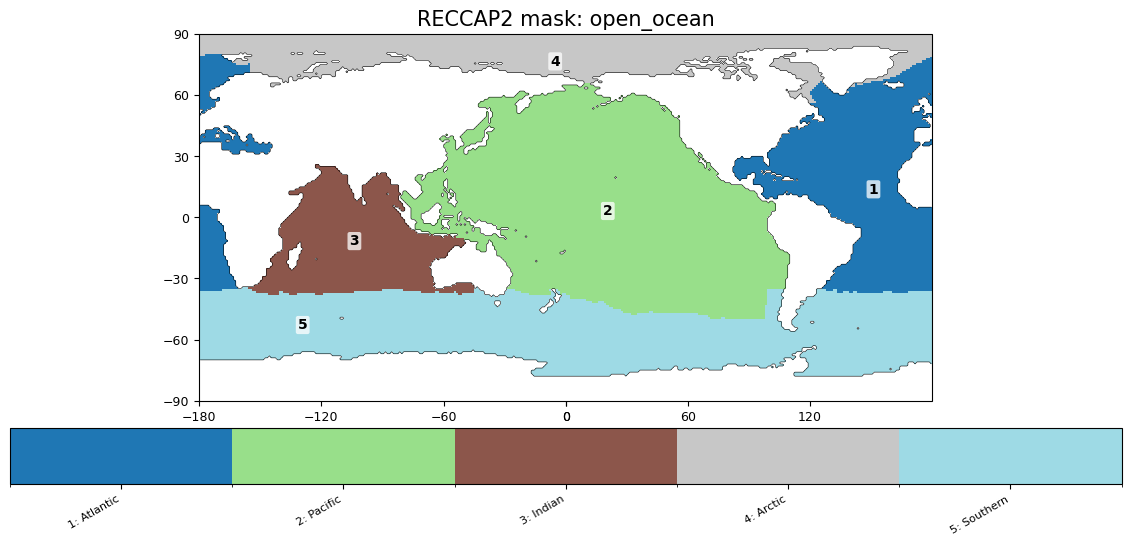

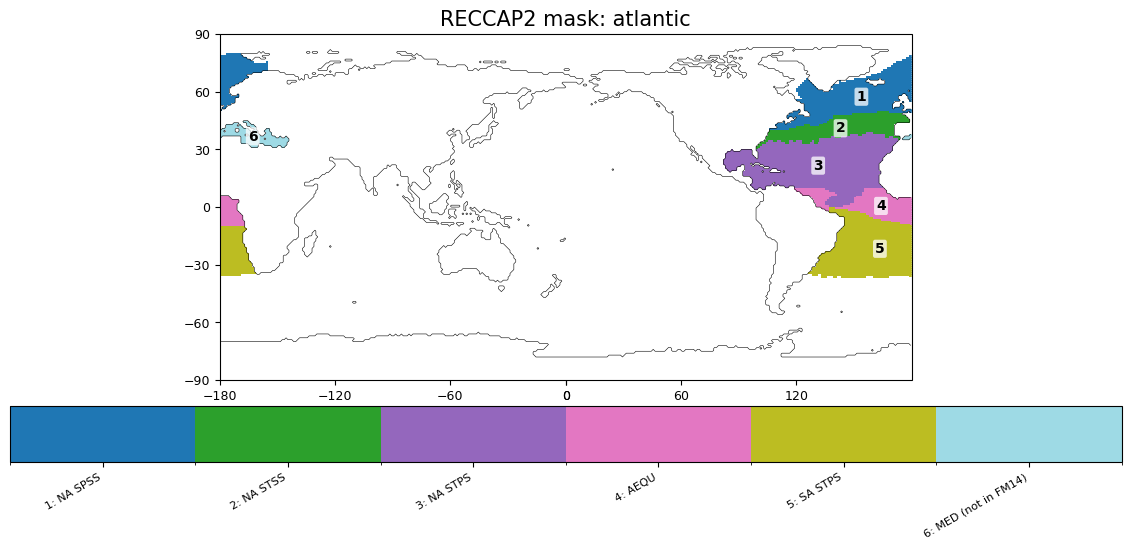

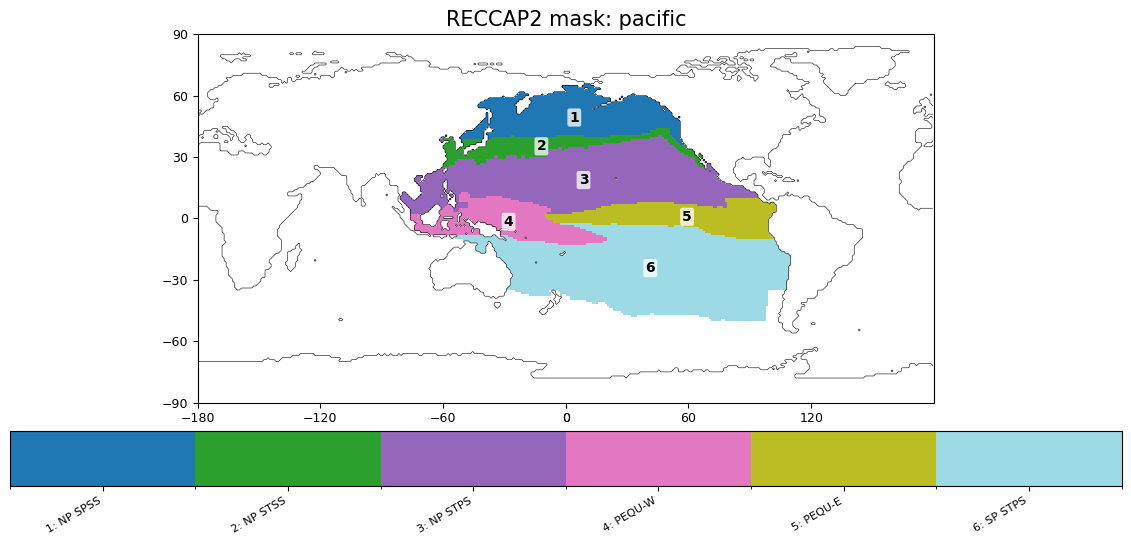

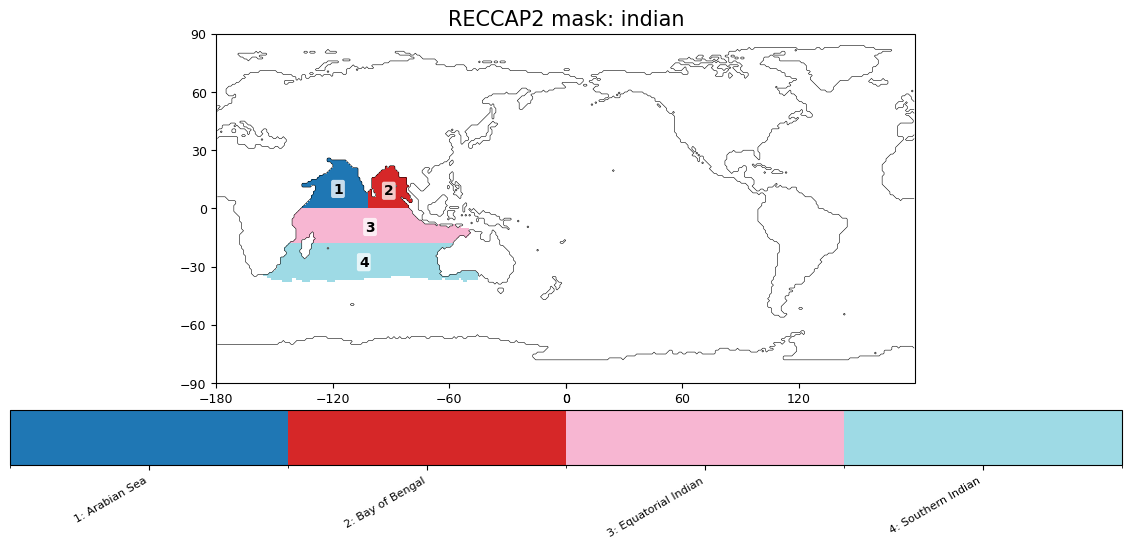

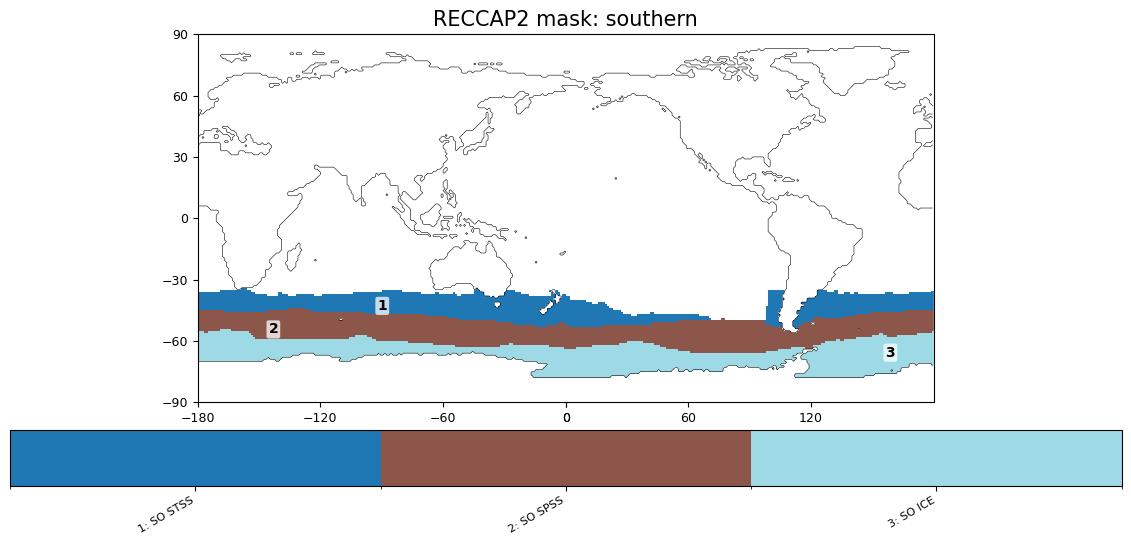

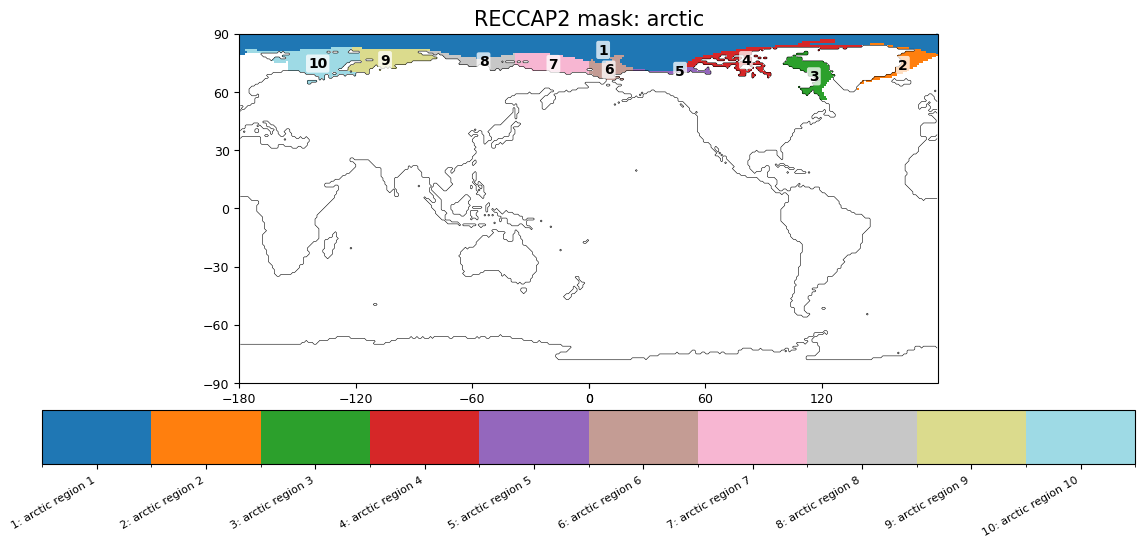

In [3]:
ds = xr.open_dataset(MASK_FILE)

for varname in MASK_VARS:
    plot_reccap2_mask(ds, varname)

In [4]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs


# ============================================================
# Settings
# ============================================================

MASK_FILE = "/nird/datalake/NS11071K/users/yongyub/RECCAP2/RECCAP2_region_masks_all_v20221025.nc"

BASIN_VARS = [
    "atlantic",
    "pacific",
    "indian",
    "southern",
    "arctic",
]


# ============================================================
# Helper functions
# ============================================================

def parse_region_names(da):
    """
    Parse region_name attribute like:
    '1.NA SPSS, 2.NA STSS, ...'
    into {1: 'NA SPSS', 2: 'NA STSS', ...}
    """
    attr = da.attrs.get("region_name", "")
    out = {}

    if not attr:
        return out

    for item in attr.split(","):
        item = item.strip()
        if "." not in item:
            continue

        key, name = item.split(".", 1)
        try:
            out[int(key.strip())] = name.strip()
        except ValueError:
            pass

    return out


def get_region_ids(da):
    vals = np.unique(da.values)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return sorted(vals.astype(int))


def weighted_centroid(lon, lat, mask):
    """
    Area-weighted centroid for label placement.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    if np.nansum(weights) == 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)
    x = np.nansum(weights * np.cos(lon_rad)) / np.nansum(weights)
    y = np.nansum(weights * np.sin(lon_rad)) / np.nansum(weights)

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / np.nansum(weights)

    return lon_c, lat_c


def lon_to_180(lon):
    return ((lon + 180) % 360) - 180


def add_basic_map(ax, ds):
    """
    Draw a simple coastline-like contour from seamask
    to avoid Cartopy download issues on HPC.
    """
    ax.set_global()
    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=9)

    if "seamask" in ds:
        ax.contour(
            ds["lon"],
            ds["lat"],
            ds["seamask"],
            levels=[0.5],
            colors="k",
            linewidths=0.4,
            transform=ccrs.PlateCarree(),
        )


def build_combined_mask(ds, basin_vars):
    """
    Combine basin-specific masks into one map with unique integer codes.
    """
    combined = xr.full_like(ds["seamask"], fill_value=0, dtype=np.int16)

    rows = []
    combined_code = 1

    for basin in basin_vars:
        da = ds[basin]
        region_ids = get_region_ids(da)
        region_names = parse_region_names(da)

        for rid in region_ids:
            combined = combined.where(da != rid, combined_code)

            rows.append(
                {
                    "combined_code": combined_code,
                    "basin": basin,
                    "original_region_id": rid,
                    "region_name": region_names.get(rid, f"{basin} region {rid}")
                }
            )

            combined_code += 1

    region_table = pd.DataFrame(rows)
    return combined, region_table


def plot_combined_reccap2_map(ds, combined, region_table):
    lon = ds["lon"].values
    lat = ds["lat"].values

    plot_da = combined.where(combined > 0)
    codes = region_table["combined_code"].values

    cmap = plt.get_cmap("tab20", len(codes)).copy()
    cmap.set_bad((1, 1, 1, 0))

    bounds = np.arange(codes.min() - 0.5, codes.max() + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    fig = plt.figure(figsize=(14, 6))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    im = ax.pcolormesh(
        lon,
        lat,
        plot_da,
        cmap=cmap,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    add_basic_map(ax, ds)
    ax.set_title("Combined RECCAP2 basin masks", fontsize=15)

    # Add labels on the map
    for code in codes:
        mask = combined.values == code
        lon_c, lat_c = weighted_centroid(lon, lat, mask)

        if np.isfinite(lon_c) and np.isfinite(lat_c):
            ax.text(
                lon_to_180(lon_c),
                lat_c,
                str(code),
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    boxstyle="round,pad=0.15",
                ),
            )

    cbar = plt.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.06,
        shrink=0.95,
        ticks=codes,
    )
    cbar.set_label("Combined region code", fontsize=10)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

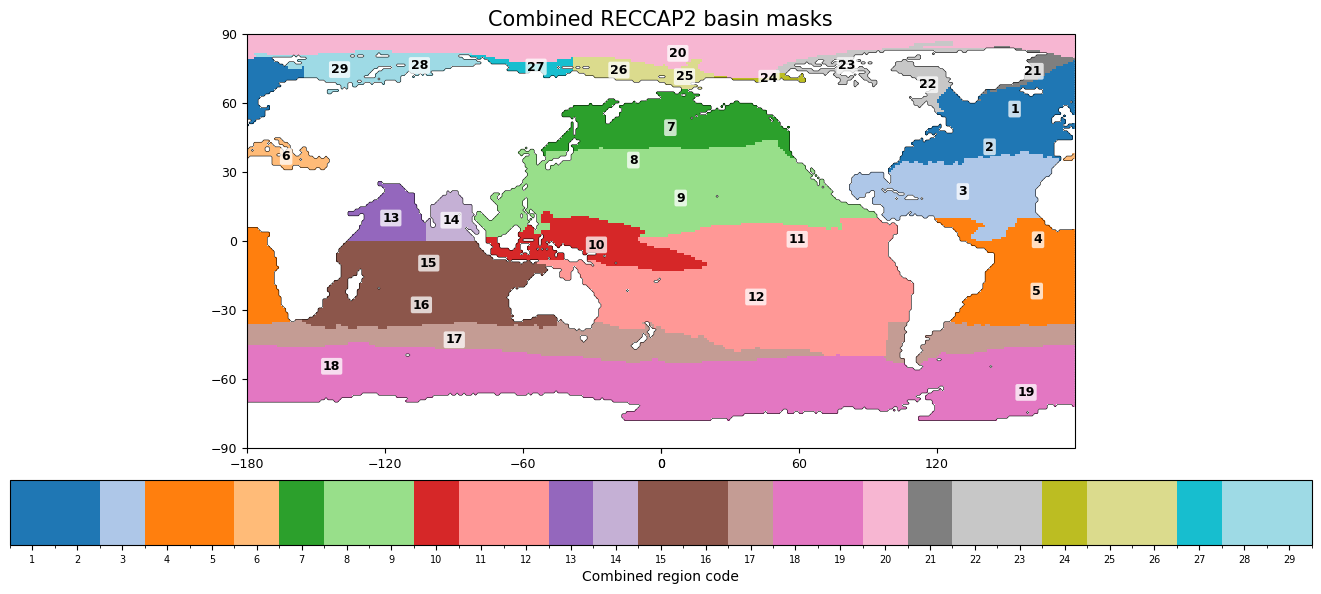

,combined_code,basin,original_region_id,region_name
0,1,atlantic,1,NA SPSS
1,2,atlantic,2,NA STSS
2,3,atlantic,3,NA STPS
3,4,atlantic,4,AEQU
4,5,atlantic,5,SA STPS
5,6,atlantic,6,MED (not in FM14)
6,7,pacific,1,NP SPSS
7,8,pacific,2,NP STSS
8,9,pacific,3,NP STPS
9,10,pacific,4,PEQU-W


In [5]:
ds = xr.open_dataset(MASK_FILE)

combined_mask, region_table = build_combined_mask(ds, BASIN_VARS)

plot_combined_reccap2_map(ds, combined_mask, region_table)

region_table

In [10]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs


# ============================================================
# Settings
# ============================================================

MASK_FILE = "/nird/datalake/NS11071K/users/yongyub/RECCAP2/RECCAP2_region_masks_all_v20221025.nc"

# Arctic is excluded entirely, so not included here
BASIN_VARS = [
    "atlantic",
    "pacific",
    "indian",
    "southern",
]

# region IDs to exclude from each basin
# EXCLUDE_REGIONS = {
#     "atlantic": [1, 6],   # 1.NA SPSS, 6.MED
#     "southern": [3],      # 3.SO ICE
#     "pacific": [],
#     "indian": [],
#     # arctic excluded entirely by not including it in BASIN_VARS
# }
EXCLUDE_REGIONS = {
    "atlantic": [6],   # 1.NA SPSS, 6.MED
    "southern": [3],      # 3.SO ICE
    "pacific": [],
    "indian": [],
    # arctic excluded entirely by not including it in BASIN_VARS
}


# ============================================================
# Helper functions
# ============================================================

def parse_region_names(da):
    attr = da.attrs.get("region_name", "")
    out = {}

    if not attr:
        return out

    for item in attr.split(","):
        item = item.strip()
        if "." not in item:
            continue

        key, name = item.split(".", 1)
        try:
            out[int(key.strip())] = name.strip()
        except ValueError:
            pass

    return out


def get_region_ids(da):
    vals = np.unique(da.values)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return sorted(vals.astype(int))


def weighted_centroid(lon, lat, mask):
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    if np.nansum(weights) == 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)
    x = np.nansum(weights * np.cos(lon_rad)) / np.nansum(weights)
    y = np.nansum(weights * np.sin(lon_rad)) / np.nansum(weights)

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / np.nansum(weights)

    return lon_c, lat_c


def lon_to_180(lon):
    return ((lon + 180) % 360) - 180


def add_basic_map(ax, ds):
    ax.set_global()
    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=9)

    if "seamask" in ds:
        ax.contour(
            ds["lon"],
            ds["lat"],
            ds["seamask"],
            levels=[0.5],
            colors="k",
            linewidths=0.4,
            transform=ccrs.PlateCarree(),
        )


# ============================================================
# Build combined mask with exclusions
# ============================================================

def build_combined_mask(ds, basin_vars, exclude_regions):
    combined = xr.full_like(ds["seamask"], fill_value=0, dtype=np.int16)

    rows = []
    combined_code = 1

    for basin in basin_vars:
        da = ds[basin]
        region_ids = get_region_ids(da)
        region_names = parse_region_names(da)

        excluded = exclude_regions.get(basin, [])

        for rid in region_ids:
            if rid in excluded:
                continue

            combined = combined.where(da != rid, combined_code)

            rows.append(
                {
                    "combined_code": combined_code,
                    "basin": basin,
                    "original_region_id": rid,
                    "region_name": region_names.get(rid, f"{basin} region {rid}")
                }
            )

            combined_code += 1

    region_table = pd.DataFrame(rows)
    return combined, region_table


# ============================================================
# Plot
# ============================================================

def plot_combined_reccap2_map(ds, combined, region_table):
    lon = ds["lon"].values
    lat = ds["lat"].values

    plot_da = combined.where(combined > 0)
    codes = region_table["combined_code"].values

    cmap = plt.get_cmap("tab20", len(codes)).copy()
    cmap.set_bad((1, 1, 1, 0))

    bounds = np.arange(codes.min() - 0.5, codes.max() + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    fig = plt.figure(figsize=(14, 6))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    im = ax.pcolormesh(
        lon,
        lat,
        plot_da,
        cmap=cmap,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    add_basic_map(ax, ds)
    ax.set_title(
        "Combined RECCAP2 basin masks\n"
        # "(excluding Southern SO ICE, Atlantic NA SPSS & MED, and all Arctic)",
        "(excluding Southern SO ICE, Atlantic MED, and all Arctic)",
        fontsize=14
    )

    for code in codes:
        mask = combined.values == code
        lon_c, lat_c = weighted_centroid(lon, lat, mask)

        if np.isfinite(lon_c) and np.isfinite(lat_c):
            ax.text(
                lon_to_180(lon_c),
                lat_c,
                str(code),
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    boxstyle="round,pad=0.15",
                ),
            )

    cbar = plt.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.06,
        shrink=0.95,
        ticks=codes,
    )
    cbar.set_label("Combined region code", fontsize=10)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

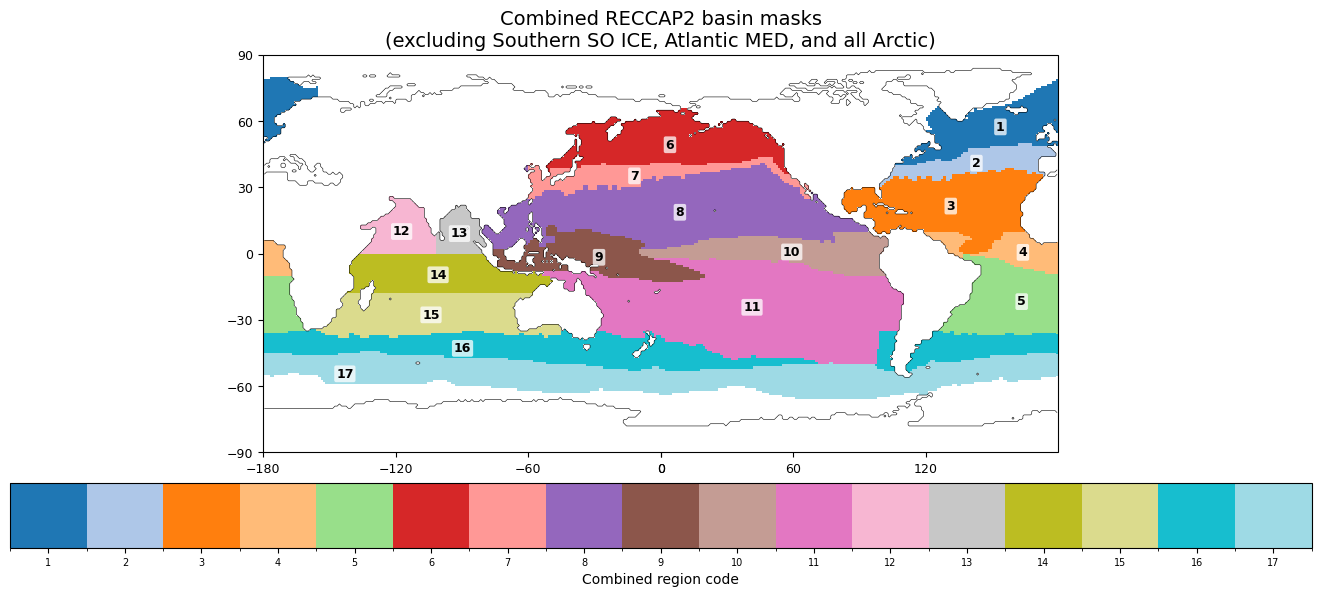

,combined_code,basin,original_region_id,region_name
0,1,atlantic,1,NA SPSS
1,2,atlantic,2,NA STSS
2,3,atlantic,3,NA STPS
3,4,atlantic,4,AEQU
4,5,atlantic,5,SA STPS
5,6,pacific,1,NP SPSS
6,7,pacific,2,NP STSS
7,8,pacific,3,NP STPS
8,9,pacific,4,PEQU-W
9,10,pacific,5,PEQU-E


In [11]:
ds = xr.open_dataset(MASK_FILE)

combined_mask, region_table = build_combined_mask(
    ds,
    BASIN_VARS,
    EXCLUDE_REGIONS,
)

plot_combined_reccap2_map(ds, combined_mask, region_table)

region_table

In [12]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs


# ============================================================
# Settings
# ============================================================

MASK_FILE = "/nird/datalake/NS11071K/users/yongyub/RECCAP2/RECCAP2_region_masks_all_v20221025.nc"

# Arctic is excluded entirely, so not included here
BASIN_VARS = [
    "atlantic",
    "pacific",
    "indian",
    "southern",
]

# region IDs to exclude from each basin
EXCLUDE_REGIONS = {
    "atlantic": [1, 6],      # 1.NA SPSS, 6.MED
    "pacific": [1],          # 1.NP SPSS
    "indian": [],
    "southern": [1, 2, 3],   # 1.SO STSS, 2.SO SPSS, 3.SO ICE
}


# ============================================================
# Plot
# ============================================================

def plot_combined_reccap2_map(ds, combined, region_table):
    lon = ds["lon"].values
    lat = ds["lat"].values

    plot_da = combined.where(combined > 0)
    codes = region_table["combined_code"].values

    cmap = plt.get_cmap("tab20", len(codes)).copy()
    cmap.set_bad((1, 1, 1, 0))

    bounds = np.arange(codes.min() - 0.5, codes.max() + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    fig = plt.figure(figsize=(14, 6))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    im = ax.pcolormesh(
        lon,
        lat,
        plot_da,
        cmap=cmap,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    add_basic_map(ax, ds)
    ax.set_title(
        "Combined RECCAP2 basin masks\n"
        "(excluding conservative high-latitude/subpolar regions)",
        fontsize=14
    )

    for code in codes:
        mask = combined.values == code
        lon_c, lat_c = weighted_centroid(lon, lat, mask)

        if np.isfinite(lon_c) and np.isfinite(lat_c):
            ax.text(
                lon_to_180(lon_c),
                lat_c,
                str(code),
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    boxstyle="round,pad=0.15",
                ),
            )

    cbar = plt.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.06,
        shrink=0.95,
        ticks=codes,
    )
    cbar.set_label("Combined region code", fontsize=10)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

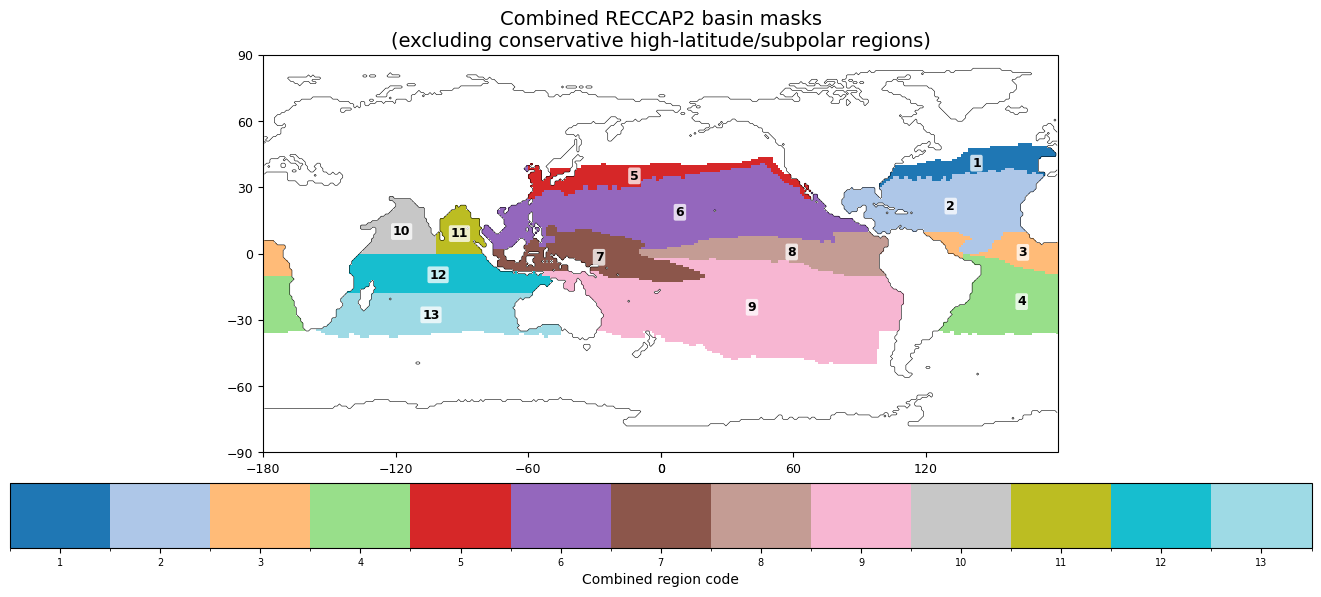

,combined_code,basin,original_region_id,region_name
0,1,atlantic,2,NA STSS
1,2,atlantic,3,NA STPS
2,3,atlantic,4,AEQU
3,4,atlantic,5,SA STPS
4,5,pacific,2,NP STSS
5,6,pacific,3,NP STPS
6,7,pacific,4,PEQU-W
7,8,pacific,5,PEQU-E
8,9,pacific,6,SP STPS
9,10,indian,1,Arabian Sea


In [13]:
ds = xr.open_dataset(MASK_FILE)

combined_mask_conservative, region_table_conservative = build_combined_mask(
    ds,
    BASIN_VARS,
    EXCLUDE_REGIONS,
)

plot_combined_reccap2_map(
    ds,
    combined_mask_conservative,
    region_table_conservative
)

region_table_conservative

In [14]:
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path
from datetime import date


# ============================================================
# Input / output
# ============================================================

MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/RECCAP2/"
    "RECCAP2_region_masks_all_v20221025.nc"
)

OUT_FILE = MASK_FILE.parent / "RECCAP2_region_mask_13regions_conservative_v20260707.nc"


# ============================================================
# Region selection
# ============================================================

BASIN_VARS = [
    "atlantic",
    "pacific",
    "indian",
    "southern",
]

# Conservative exclusion
EXCLUDE_REGIONS = {
    "atlantic": [1, 6],      # 1.NA SPSS, 6.MED
    "pacific": [1],          # 1.NP SPSS
    "indian": [],
    "southern": [1, 2, 3],   # 1.SO STSS, 2.SO SPSS, 3.SO ICE
}


# ============================================================
# Helper functions
# ============================================================

def parse_region_names(da):
    """
    Parse region_name attribute:
    '1.NA SPSS, 2.NA STSS, ...'
    """
    attr = da.attrs.get("region_name", "")
    out = {}

    if not attr:
        return out

    for item in attr.split(","):
        item = item.strip()

        if "." not in item:
            continue

        key, name = item.split(".", 1)

        try:
            out[int(key.strip())] = name.strip()
        except ValueError:
            pass

    return out


def get_region_ids(da):
    vals = np.unique(da.values)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return sorted(vals.astype(int))


def build_13region_mask(ds, basin_vars, exclude_regions):
    """
    Build a new combined RECCAP2 mask.

    Output:
        0   = excluded / outside selected regions
        1-13 = selected conservative RECCAP2 regions
    """
    combined = xr.full_like(ds["seamask"], fill_value=0, dtype=np.int8)

    rows = []
    combined_code = 1

    for basin in basin_vars:
        da = ds[basin]
        region_ids = get_region_ids(da)
        region_names = parse_region_names(da)
        excluded = exclude_regions.get(basin, [])

        for rid in region_ids:
            if rid in excluded:
                continue

            region_name = region_names.get(rid, f"{basin} region {rid}")

            combined = combined.where(da != rid, combined_code)

            rows.append(
                {
                    "combined_code": combined_code,
                    "basin": basin,
                    "original_region_id": rid,
                    "region_name": region_name,
                }
            )

            combined_code += 1

    region_table = pd.DataFrame(rows)

    if len(region_table) != 13:
        raise ValueError(f"Expected 13 regions, but got {len(region_table)}")

    return combined, region_table


# ============================================================
# Main
# ============================================================

ds = xr.open_dataset(MASK_FILE)

region_mask, region_table = build_13region_mask(
    ds,
    BASIN_VARS,
    EXCLUDE_REGIONS,
)

print(region_table.to_string(index=False))


# ============================================================
# Create output dataset
# ============================================================

# Attribute string like:
# "1.NA STSS, 2.NA STPS, ..."
region_name_attr = ", ".join(
    [
        f"{row.combined_code}.{row.region_name}"
        for row in region_table.itertuples(index=False)
    ]
)

# More detailed provenance string
region_source_attr = ", ".join(
    [
        f"{row.combined_code}.{row.basin}:{row.original_region_id}.{row.region_name}"
        for row in region_table.itertuples(index=False)
    ]
)

excluded_attr = (
    "atlantic: 1.NA SPSS, 6.MED; "
    "pacific: 1.NP SPSS; "
    "southern: 1.SO STSS, 2.SO SPSS, 3.SO ICE; "
    "arctic: all excluded"
)

out_ds = xr.Dataset(
    data_vars={
        "region_mask": region_mask.astype("int8"),
    },
    coords={
        "lat": ds["lat"],
        "lon": ds["lon"],
    },
    attrs=ds.attrs.copy(),
)

# Variable attributes
out_ds["region_mask"].attrs.update(
    {
        "long_name": "Conservative 13-region RECCAP2 ocean mask",
        "description": (
            "Combined RECCAP2 regional mask after excluding selected "
            "high-latitude, ice, Mediterranean, and Arctic regions. "
            "0 indicates excluded or non-selected areas; 1-13 indicate "
            "selected RECCAP2 regions."
        ),
        "units": "1",
        "valid_min": np.int8(0),
        "valid_max": np.int8(13),
        "region_name": region_name_attr,
        "region_source": region_source_attr,
        "excluded_regions": excluded_attr,
    }
)

# Coordinate attributes are preserved automatically, but keep explicitly
out_ds["lat"].attrs = ds["lat"].attrs.copy()
out_ds["lon"].attrs = ds["lon"].attrs.copy()

# Update global attributes
out_ds.attrs.update(
    {
        "title": "Conservative 13-region RECCAP2 ocean mask",
        "description": (
            "Conservative combined RECCAP2 ocean mask derived from "
            "RECCAP2_region_masks_all_v20221025.nc. "
            "The mask combines Atlantic, Pacific, Indian, and Southern "
            "subregions after excluding Atlantic NA SPSS and MED, "
            "Pacific NP SPSS, all Southern Ocean subregions, and all Arctic."
        ),
        "source_file": str(MASK_FILE),
        "created_by": "custom script based on RECCAP2 region masks",
        "date_created": date.today().isoformat(),
    }
)


# ============================================================
# Save netCDF
# ============================================================

encoding = {
    "region_mask": {
        "dtype": "int8",
        "_FillValue": None,
        "zlib": True,
        "complevel": 4,
    },
    "lat": {
        "dtype": "float64",
        "_FillValue": None,
    },
    "lon": {
        "dtype": "float64",
        "_FillValue": None,
    },
}

out_ds.to_netcdf(OUT_FILE, encoding=encoding)

print(f"\nSaved: {OUT_FILE}")

 combined_code    basin  original_region_id       region_name
             1 atlantic                   2           NA STSS
             2 atlantic                   3           NA STPS
             3 atlantic                   4              AEQU
             4 atlantic                   5           SA STPS
             5  pacific                   2           NP STSS
             6  pacific                   3           NP STPS
             7  pacific                   4            PEQU-W
             8  pacific                   5            PEQU-E
             9  pacific                   6           SP STPS
            10   indian                   1       Arabian Sea
            11   indian                   2     Bay of Bengal
            12   indian                   3 Equatorial Indian
            13   indian                   4   Southern Indian

Saved: /nird/datalake/NS11071K/users/yongyub/RECCAP2/RECCAP2_region_mask_13regions_conservative_v20260707.nc


Region table:
 region    basin  original_region_id       region_name
      1 atlantic                   1           NA SPSS
      2 atlantic                   2           NA STSS
      3 atlantic                   3           NA STPS
      4 atlantic                   4              AEQU
      5 atlantic                   5           SA STPS
      6 atlantic                   6 MED (not in FM14)
      7  pacific                   1           NP SPSS
      8  pacific                   2           NP STSS
      9  pacific                   3           NP STPS
     10  pacific                   4            PEQU-W
     11  pacific                   5            PEQU-E
     12  pacific                   6           SP STPS
     13   indian                   1       Arabian Sea
     14   indian                   2     Bay of Bengal
     15   indian                   3 Equatorial Indian
     16   indian                   4   Southern Indian
     17   arctic                   1   arctic regio

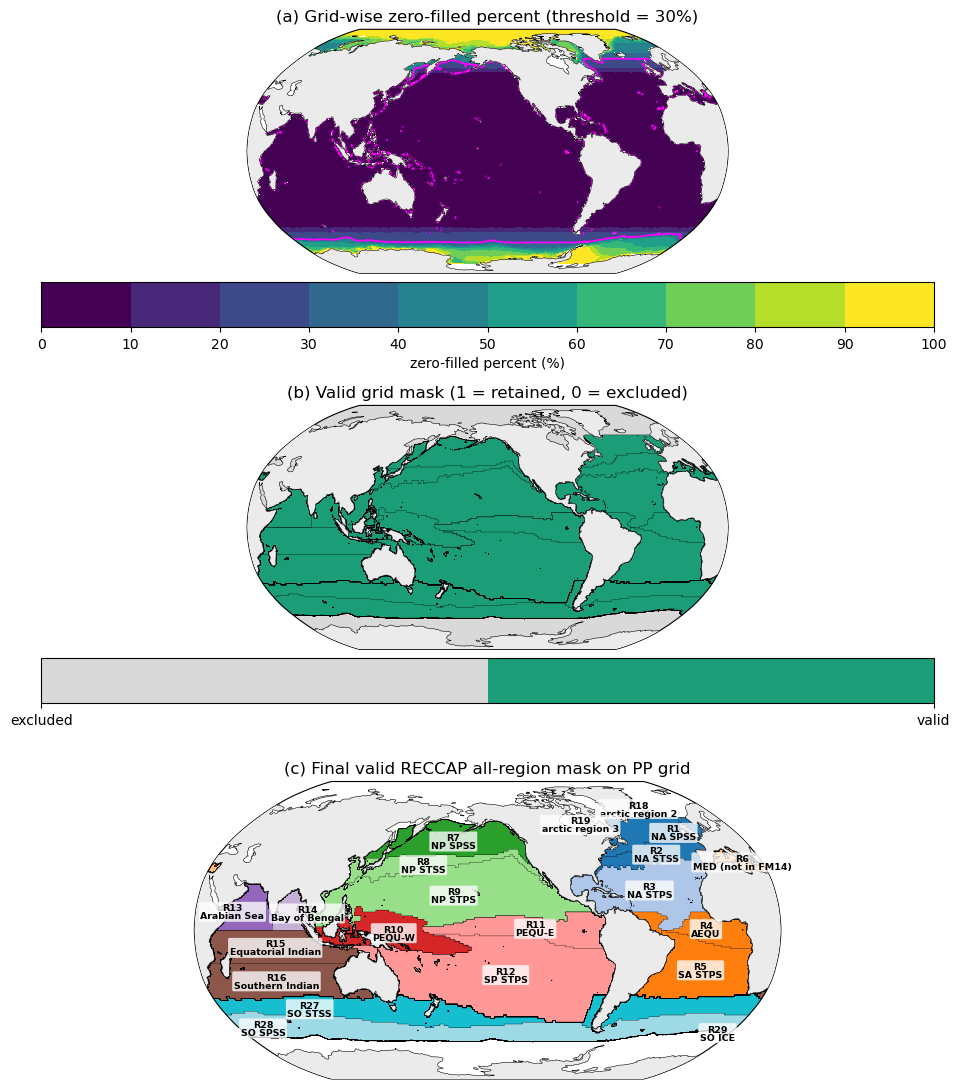

Saved figure: /nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/GlobColour_PP_grid_validity_RECCAP2_all_regions/valid_mask_zero30/RECCAP2_all_regions_valid_mask_zero30_map.png


In [21]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import date
from matplotlib.colors import BoundaryNorm, ListedColormap


# ============================================================
# Input / output
# ============================================================

# Original RECCAP all-region mask
MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/RECCAP2/"
    "RECCAP2_region_masks_all_v20221025.nc"
)

# Grid-wise PP validity file made previously
VALIDITY_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/"
    "GlobColour_PP_grid_validity_RECCAP2_all_regions/"
    "GlobColour_PP_grid_validity_percent_RECCAP2_all_regions_1998_2025.nc"
)

OUT_DIR = VALIDITY_FILE.parent / "valid_mask_zero30"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_MASK_FILE = OUT_DIR / "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
OUT_SUMMARY_FILE = OUT_DIR / "RECCAP2_all_regions_valid_mask_zero30_summary.csv"
OUT_FIG_FILE = OUT_DIR / "RECCAP2_all_regions_valid_mask_zero30_map.png"


# ============================================================
# Settings
# ============================================================

# Must match the basin order used when you previously created
# region_mask_on_pp_grid
BASIN_VARS = ["atlantic", "pacific", "indian", "arctic", "southern"]

ZERO_THRESHOLD = 30.0   # keep only grid cells with zero_filled_percent <= 30%

CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4
SHOW_REGION_LABELS = True

# Optional manual offsets in degree units if labels overlap.
# Format: region_code: (dlon, dlat)
REGION_LABEL_OFFSETS = {
    19: (-22,  0),   # R19: move left
    18: ( 16,  6),   # R18: move right and upward
    1:  ( 18,  0),   # R1 : move right

    13: (-10,  0),   # R13: move left
    14: ( 10,  0),   # R14: move right
}

# ============================================================
# Helper functions
# ============================================================

def parse_region_names(da):
    """
    Parse region_name attribute:
    '1.NA SPSS, 2.NA STSS, ...'
    """
    attr = da.attrs.get("region_name", "")
    out = {}

    if not attr:
        return out

    for item in attr.split(","):
        item = item.strip()

        if "." not in item:
            continue

        key, name = item.split(".", 1)

        try:
            out[int(key.strip())] = name.strip()
        except ValueError:
            pass

    return out


def get_region_ids(da):
    vals = np.unique(da.values)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return sorted(vals.astype(int))


def build_region_table_all(ds, basin_vars):
    """
    Build region table with sequential combined_code = 1..N
    following basin_vars order and original region IDs.
    This must match the code order used in the PP-grid all-region mask.
    """
    rows = []
    combined_code = 1

    for basin in basin_vars:
        da = ds[basin]
        region_ids = get_region_ids(da)
        region_names = parse_region_names(da)

        for rid in region_ids:
            region_name = region_names.get(rid, f"{basin} region {rid}")

            rows.append(
                {
                    "region": combined_code,
                    "basin": basin,
                    "original_region_id": rid,
                    "region_name": region_name,
                }
            )

            combined_code += 1

    return pd.DataFrame(rows)


def add_cyclic_manual(data, lon):
    """
    Add a cyclic column without requiring equally spaced longitude.
    """
    lon = np.asarray(lon, dtype=np.float64)

    sort_idx = np.argsort(lon)
    lon_sorted = lon[sort_idx]
    data_sorted = data[:, sort_idx]

    dlon = float(np.nanmedian(np.diff(lon_sorted)))

    lon_cyc = np.concatenate([lon_sorted, [lon_sorted[-1] + dlon]])
    data_cyc = np.concatenate([data_sorted, data_sorted[:, :1]], axis=1)

    return data_cyc, lon_cyc

def lon_to_180(lon):
    """
    Convert longitude to -180..180 convention for Cartopy text placement.
    """
    return ((lon + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, mask):
    """
    Area-weighted centroid using cosine latitude weights.
    Longitude centroid is circular.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    wsum = np.nansum(weights)

    if wsum <= 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)

    x = np.nansum(weights * np.cos(lon_rad)) / wsum
    y = np.nansum(weights * np.sin(lon_rad)) / wsum

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / wsum

    return lon_c, lat_c


def make_region_label(region, region_name):
    """
    Compact region label for map annotation.
    """
    return f"R{int(region)}\n{region_name}"
    

# ============================================================
# Load files
# ============================================================

mask_ds = xr.open_dataset(MASK_FILE)
valid_ds = xr.open_dataset(VALIDITY_FILE)

region_table = build_region_table_all(mask_ds, BASIN_VARS)

print("Region table:")
print(region_table.to_string(index=False))

lat = valid_ds["latitude"].values.astype(float)
lon = valid_ds["longitude"].values.astype(float)

zero_pct = valid_ds["zero_filled_percent"].values.astype(float)
region_mask_pp = valid_ds["region_mask_on_pp_grid"].values.astype(np.int16)

nlat, nlon = zero_pct.shape


# ============================================================
# Build valid mask on PP grid
# ============================================================

# original domain
inside_region = region_mask_pp > 0

# valid if inside RECCAP region and zero_filled_percent <= threshold
valid_cell = inside_region & np.isfinite(zero_pct) & (zero_pct <= ZERO_THRESHOLD)

# New integer valid mask:
# 0 = excluded
# 1..N = original RECCAP all-region code where valid
valid_region_mask = np.where(valid_cell, region_mask_pp, 0).astype(np.int16)

# Optional float version for plotting
valid_region_mask_nan = np.where(valid_region_mask > 0, valid_region_mask.astype(float), np.nan)


# ============================================================
# Region-level summary
# ============================================================

rows = []

for code in sorted(np.unique(region_mask_pp[region_mask_pp > 0])):
    code = int(code)

    orig = region_mask_pp == code
    valid = valid_region_mask == code

    n_total = int(np.sum(orig))
    n_valid = int(np.sum(valid))
    n_excluded = n_total - n_valid

    valid_fraction = np.nan
    if n_total > 0:
        valid_fraction = 100.0 * n_valid / n_total

    # mean zero-filled percent over original region
    mean_zero_all = np.nan
    if np.any(orig):
        mean_zero_all = float(np.nanmean(zero_pct[orig]))

    # mean zero-filled percent over retained grids
    mean_zero_valid = np.nan
    if np.any(valid):
        mean_zero_valid = float(np.nanmean(zero_pct[valid]))

    info = region_table.loc[region_table["region"] == code]
    if len(info) > 0:
        info = info.iloc[0]
        basin = info["basin"]
        original_region_id = int(info["original_region_id"])
        region_name = info["region_name"]
    else:
        basin = ""
        original_region_id = -999
        region_name = f"region {code}"

    rows.append(
        {
            "region": code,
            "basin": basin,
            "original_region_id": original_region_id,
            "region_name": region_name,
            "n_total_cells": n_total,
            "n_valid_cells": n_valid,
            "n_excluded_cells": n_excluded,
            "valid_fraction_percent": valid_fraction,
            "mean_zero_filled_percent_all_cells": mean_zero_all,
            "mean_zero_filled_percent_valid_cells": mean_zero_valid,
            "region_fully_excluded": bool(n_valid == 0),
        }
    )

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUT_SUMMARY_FILE, index=False)

print("\nSummary:")
print(summary_df.to_string(index=False))

print("\nRegions fully excluded:")
print(summary_df.loc[summary_df["region_fully_excluded"], ["region", "region_name"]].to_string(index=False))


# ============================================================
# Save valid mask file
# ============================================================

region_name_attr = ", ".join(
    [
        f"{row.region}.{row.region_name}"
        for row in summary_df.itertuples(index=False)
    ]
)

region_source_attr = ", ".join(
    [
        f"{row.region}.{row.basin}:{row.original_region_id}.{row.region_name}"
        for row in summary_df.itertuples(index=False)
    ]
)

out_ds = xr.Dataset(
    data_vars={
        "valid_region_mask": (
            ("latitude", "longitude"),
            valid_region_mask,
            {
                "long_name": "RECCAP2 all-region valid mask on GlobColour PP grid",
                "description": (
                    "Grid cells are retained only where zero_filled_percent <= "
                    f"{ZERO_THRESHOLD}%. "
                    "0 indicates excluded grid cells; positive integers indicate "
                    "retained RECCAP region codes."
                ),
                "units": "1",
                "valid_min": np.int16(0),
                "valid_max": np.int16(np.nanmax(valid_region_mask)),
                "region_name": region_name_attr,
                "region_source": region_source_attr,
                "zero_filled_threshold_percent": ZERO_THRESHOLD,
            },
        ),
        "zero_filled_percent": (
            ("latitude", "longitude"),
            zero_pct.astype(np.float32),
            {
                "long_name": "Percentage of monthly files where PP was zero-filled",
                "units": "%",
            },
        ),
        "original_region_mask_on_pp_grid": (
            ("latitude", "longitude"),
            region_mask_pp.astype(np.int16),
            {
                "long_name": "Original RECCAP2 all-region mask on PP grid",
                "units": "1",
            },
        ),
        "valid_cell": (
            ("latitude", "longitude"),
            valid_cell.astype(np.int8),
            {
                "long_name": "Binary valid-cell mask",
                "description": f"1 where zero_filled_percent <= {ZERO_THRESHOLD}%, else 0.",
                "units": "1",
            },
        ),
        "region_name": (
            ("region",),
            summary_df["region_name"].values.astype(object),
        ),
        "basin": (
            ("region",),
            summary_df["basin"].values.astype(object),
        ),
        "original_region_id": (
            ("region",),
            summary_df["original_region_id"].values.astype(np.int16),
        ),
        "n_total_cells": (
            ("region",),
            summary_df["n_total_cells"].values.astype(np.int32),
        ),
        "n_valid_cells": (
            ("region",),
            summary_df["n_valid_cells"].values.astype(np.int32),
        ),
        "valid_fraction_percent": (
            ("region",),
            summary_df["valid_fraction_percent"].values.astype(np.float32),
        ),
        "region_fully_excluded": (
            ("region",),
            summary_df["region_fully_excluded"].values.astype(np.int8),
        ),
    },
    coords={
        "latitude": lat,
        "longitude": lon,
        "region": summary_df["region"].values.astype(np.int16),
    },
    attrs={
        "title": "RECCAP2 all-region valid mask based on PP zero-filled percentage",
        "description": (
            "Original all-region RECCAP2 mask filtered using grid-wise "
            f"zero_filled_percent <= {ZERO_THRESHOLD}%. "
            "Regions with zero valid cells are effectively excluded from later analysis."
        ),
        "source_reccap_mask_file": str(MASK_FILE),
        "source_pp_validity_file": str(VALIDITY_FILE),
        "created_by": "custom script",
        "date_created": date.today().isoformat(),
    }
)

encoding = {
    "valid_region_mask": {"dtype": "int16", "_FillValue": None, "zlib": True, "complevel": 4},
    "zero_filled_percent": {"dtype": "float32", "_FillValue": np.float32(-999.0), "zlib": True, "complevel": 4},
    "original_region_mask_on_pp_grid": {"dtype": "int16", "_FillValue": None, "zlib": True, "complevel": 4},
    "valid_cell": {"dtype": "int8", "_FillValue": None, "zlib": True, "complevel": 4},
    "original_region_id": {"dtype": "int16", "_FillValue": None},
    "n_total_cells": {"dtype": "int32", "_FillValue": None},
    "n_valid_cells": {"dtype": "int32", "_FillValue": None},
    "valid_fraction_percent": {"dtype": "float32", "_FillValue": np.float32(-999.0)},
    "region_fully_excluded": {"dtype": "int8", "_FillValue": None},
    "region": {"dtype": "int16", "_FillValue": None},
}

out_ds.to_netcdf(OUT_MASK_FILE, encoding=encoding, engine="netcdf4")

print(f"\nSaved valid mask: {OUT_MASK_FILE}")
print(f"Saved summary   : {OUT_SUMMARY_FILE}")


# ============================================================
# Plot maps
# ============================================================

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    has_cartopy = True
except ImportError:
    has_cartopy = False


# For plotting only: coarsen
lat_plot = lat[::PLOT_STRIDE]
lon_plot = lon[::PLOT_STRIDE]

zero_plot = zero_pct[::PLOT_STRIDE, ::PLOT_STRIDE]
valid_plot = valid_cell[::PLOT_STRIDE, ::PLOT_STRIDE].astype(float)
region_plot = valid_region_mask[::PLOT_STRIDE, ::PLOT_STRIDE].astype(float)

zero_cyc, lon_cyc = add_cyclic_manual(zero_plot, lon_plot)
valid_cyc, _ = add_cyclic_manual(valid_plot, lon_plot)
region_cyc, _ = add_cyclic_manual(region_plot, lon_plot)

# region boundaries
boundary_levels = np.arange(
    0.5,
    int(np.nanmax(region_mask_pp)) + 1.5,
    1.0,
)

# Panel 1: 10% bins for zero-filled percent
zero_bounds = np.arange(0, 101, 10)
zero_cmap = plt.get_cmap("viridis", len(zero_bounds) - 1)
zero_norm = BoundaryNorm(zero_bounds, ncolors=len(zero_bounds) - 1, clip=True)

# Panel 2: binary valid mask
valid_cmap = ListedColormap(["0.85", "#1b9e77"])  # excluded, valid

# Panel 3: categorical region colors
n_region = int(np.nanmax(region_mask_pp))
region_cmap = plt.get_cmap("tab20", max(n_region, 20))

if has_cartopy:
    fig = plt.figure(figsize=(16, 11))

    # --------------------------------------------------------
    # (a) zero_filled_percent + threshold contour
    # --------------------------------------------------------
    ax1 = plt.subplot(3, 1, 1, projection=ccrs.Robinson(central_longitude=CENTRAL_LONGITUDE))

    im1 = ax1.pcolormesh(
        lon_cyc,
        lat_plot,
        zero_cyc,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=zero_cmap,
        norm=zero_norm,
    )

    # threshold contour
    ax1.contour(
        lon_cyc,
        lat_plot,
        zero_cyc,
        levels=[ZERO_THRESHOLD],
        colors="magenta",
        linewidths=1.2,
        transform=ccrs.PlateCarree(),
    )

    ax1.add_feature(cfeature.LAND, facecolor="0.92", edgecolor="none", zorder=3)
    ax1.coastlines(linewidth=0.4, zorder=4)
    ax1.set_global()

    cbar1 = plt.colorbar(
        im1,
        ax=ax1,
        orientation="horizontal",
        pad=0.03,
        shrink=0.75,
        boundaries=zero_bounds,
        ticks=zero_bounds,
    )
    cbar1.set_label("zero-filled percent (%)")

    ax1.set_title(
        f"(a) Grid-wise zero-filled percent (threshold = {ZERO_THRESHOLD:.0f}%)"
    )

    # --------------------------------------------------------
    # (b) binary valid mask
    # --------------------------------------------------------
    ax2 = plt.subplot(3, 1, 2, projection=ccrs.Robinson(central_longitude=CENTRAL_LONGITUDE))

    im2 = ax2.pcolormesh(
        lon_cyc,
        lat_plot,
        valid_cyc,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=valid_cmap,
        vmin=0,
        vmax=1,
    )

    ax2.contour(
        lon_cyc,
        lat_plot,
        region_cyc,
        levels=boundary_levels,
        colors="k",
        linewidths=0.25,
        transform=ccrs.PlateCarree(),
    )

    ax2.add_feature(cfeature.LAND, facecolor="0.92", edgecolor="none", zorder=3)
    ax2.coastlines(linewidth=0.4, zorder=4)
    ax2.set_global()

    cbar2 = plt.colorbar(
        im2,
        ax=ax2,
        orientation="horizontal",
        pad=0.03,
        shrink=0.75,
        ticks=[0, 1],
    )
    cbar2.ax.set_xticklabels(["excluded", "valid"])

    ax2.set_title("(b) Valid grid mask (1 = retained, 0 = excluded)")

    # --------------------------------------------------------
    # (c) valid RECCAP region mask
    # --------------------------------------------------------
    ax3 = plt.subplot(3, 1, 3, projection=ccrs.Robinson(central_longitude=CENTRAL_LONGITUDE))

    region_masked = np.ma.masked_where(region_cyc == 0, region_cyc)

    im3 = ax3.pcolormesh(
        lon_cyc,
        lat_plot,
        region_masked,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=region_cmap,
        vmin=1,
        vmax=max(n_region, 20),
    )

    ax3.contour(
        lon_cyc,
        lat_plot,
        region_cyc,
        levels=boundary_levels,
        colors="k",
        linewidths=0.25,
        transform=ccrs.PlateCarree(),
    )

    ax3.add_feature(cfeature.LAND, facecolor="0.92", edgecolor="none", zorder=3)
    ax3.coastlines(linewidth=0.4, zorder=4)
    ax3.set_global()
    
    # --------------------------------------------------------
    # Add region labels
    # --------------------------------------------------------
    if SHOW_REGION_LABELS:
        label_df = summary_df.loc[summary_df["region_fully_excluded"] == False].copy()
    
        for row in label_df.itertuples(index=False):
            code = int(row.region)
            region_name = str(row.region_name)
    
            this_mask = valid_region_mask == code
    
            if not np.any(this_mask):
                continue
    
            lon_c, lat_c = weighted_centroid(lon, lat, this_mask)
    
            if not (np.isfinite(lon_c) and np.isfinite(lat_c)):
                continue
    
            dlon, dlat = REGION_LABEL_OFFSETS.get(code, (0.0, 0.0))
    
            label = make_region_label(code, region_name)
    
            ax3.text(
                lon_to_180(lon_c + dlon),
                lat_c + dlat,
                label,
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=6.8,
                fontweight="bold",
                linespacing=0.85,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.78,
                    boxstyle="round,pad=0.16",
                ),
                zorder=5,
            )
    
    ax3.set_title("(c) Final valid RECCAP all-region mask on PP grid")

else:
    fig, axes = plt.subplots(3, 1, figsize=(14, 11))

    ax1, ax2, ax3 = axes

    im1 = ax1.pcolormesh(
        lon_cyc,
        lat_plot,
        zero_cyc,
        shading="auto",
        cmap=zero_cmap,
        norm=zero_norm,
    )
    ax1.contour(
        lon_cyc,
        lat_plot,
        zero_cyc,
        levels=[ZERO_THRESHOLD],
        colors="magenta",
        linewidths=1.2,
    )
    plt.colorbar(im1, ax=ax1, boundaries=zero_bounds, ticks=zero_bounds)
    ax1.set_title(f"(a) Grid-wise zero-filled percent (threshold = {ZERO_THRESHOLD:.0f}%)")
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")

    im2 = ax2.pcolormesh(
        lon_cyc,
        lat_plot,
        valid_cyc,
        shading="auto",
        cmap=valid_cmap,
        vmin=0,
        vmax=1,
    )
    ax2.contour(
        lon_cyc,
        lat_plot,
        region_cyc,
        levels=boundary_levels,
        colors="k",
        linewidths=0.25,
    )
    cbar2 = plt.colorbar(im2, ax=ax2, ticks=[0, 1])
    cbar2.ax.set_xticklabels(["excluded", "valid"])
    ax2.set_title("(b) Valid grid mask (1 = retained, 0 = excluded)")
    ax2.set_xlabel("Longitude")
    ax2.set_ylabel("Latitude")

    region_masked = np.ma.masked_where(region_cyc == 0, region_cyc)
    im3 = ax3.pcolormesh(
        lon_cyc,
        lat_plot,
        region_masked,
        shading="auto",
        cmap=region_cmap,
        vmin=1,
        vmax=max(n_region, 20),
    )
    ax3.contour(
        lon_cyc,
        lat_plot,
        region_cyc,
        levels=boundary_levels,
        colors="k",
        linewidths=0.25,
    )
    plt.colorbar(im3, ax=ax3)
    if SHOW_REGION_LABELS:
        label_df = summary_df.loc[summary_df["region_fully_excluded"] == False].copy()

    for row in label_df.itertuples(index=False):
        code = int(row.region)
        region_name = str(row.region_name)

        this_mask = valid_region_mask == code

        if not np.any(this_mask):
            continue

        lon_c, lat_c = weighted_centroid(lon, lat, this_mask)

        if not (np.isfinite(lon_c) and np.isfinite(lat_c)):
            continue

        dlon, dlat = REGION_LABEL_OFFSETS.get(code, (0.0, 0.0))

        ax3.text(
            lon_c + dlon,
            lat_c + dlat,
            make_region_label(code, region_name),
            ha="center",
            va="center",
            fontsize=6.8,
            fontweight="bold",
            linespacing=0.85,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.78,
                boxstyle="round,pad=0.16",
            ),
            zorder=5,
        )
    ax3.set_title("(c) Final valid RECCAP all-region mask on PP grid")
    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")

plt.tight_layout()
# plt.savefig(OUT_FIG_FILE, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure: {OUT_FIG_FILE}")

Regions shown:
[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 27, 28]
Regions excluded:
[6, 18, 19, 29]


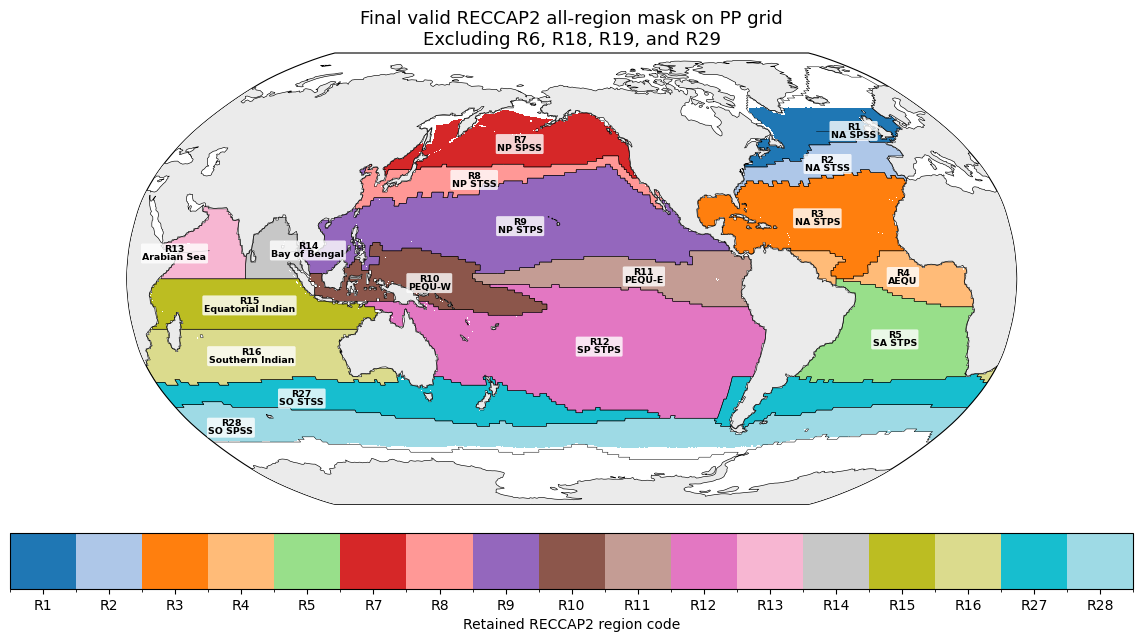

Saved: /nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/GlobColour_PP_grid_validity_RECCAP2_all_regions/valid_mask_zero30/RECCAP2_valid_zero30_panel_c_excluding_R6_R18_R19_R29.png


In [22]:
# ============================================================
# Standalone panel (c): final valid RECCAP mask
# excluding selected regions
# ============================================================

EXCLUDE_PLOT_REGIONS = [6, 18, 19, 29]

PANEL_C_OUT_FIG = OUT_DIR / (
    "RECCAP2_valid_zero30_panel_c_excluding_R6_R18_R19_R29.png"
)

SHOW_REGION_LABELS = True

# Label offsets in degree units.
# Only needed for overlapping labels.
REGION_LABEL_OFFSETS = {
    1:  (18,  0),
    13: (-14, -1),
    14: ( 14,  1),
}

# ------------------------------------------------------------
# Make plotting masks
# ------------------------------------------------------------

# valid_region_mask: final valid-zero30 mask
# original_region_mask: original RECCAP mask on PP grid
#
# If original_region_mask is not already defined, recover it from out_ds.
if "original_region_mask" not in globals():
    if "out_ds" in globals() and "original_region_mask_on_pp_grid" in out_ds:
        original_region_mask = out_ds["original_region_mask_on_pp_grid"].values.astype(np.int16)
    elif "valid_ds" in globals() and "original_region_mask_on_pp_grid" in valid_ds:
        original_region_mask = valid_ds["original_region_mask_on_pp_grid"].values.astype(np.int16)
    else:
        raise NameError(
            "original_region_mask is not defined. "
            "Define it from original_region_mask_on_pp_grid first."
        )

plot_region_mask = valid_region_mask.copy().astype(np.int16)
plot_original_region_mask = original_region_mask.copy().astype(np.int16)

for code in EXCLUDE_PLOT_REGIONS:
    plot_region_mask[plot_region_mask == code] = 0
    plot_original_region_mask[plot_original_region_mask == code] = 0

region_codes_plot = sorted(
    [int(c) for c in np.unique(plot_region_mask) if c > 0]
)

print("Regions shown:")
print(region_codes_plot)

print("Regions excluded:")
print(EXCLUDE_PLOT_REGIONS)


# ------------------------------------------------------------
# Remap region codes to compact color indices
# ------------------------------------------------------------

code_to_color_index = {
    code: i + 1 for i, code in enumerate(region_codes_plot)
}

color_index_to_code = {
    i + 1: code for i, code in enumerate(region_codes_plot)
}

plot_region_index = np.zeros_like(plot_region_mask, dtype=np.int16)

for code, idx in code_to_color_index.items():
    plot_region_index[plot_region_mask == code] = idx


# ------------------------------------------------------------
# Coarsen only for plotting
# ------------------------------------------------------------

lat_plot = lat[::PLOT_STRIDE]
lon_plot = lon[::PLOT_STRIDE]

region_index_plot = plot_region_index[::PLOT_STRIDE, ::PLOT_STRIDE].astype(float)
original_region_plot = plot_original_region_mask[::PLOT_STRIDE, ::PLOT_STRIDE].astype(float)

region_index_cyc, lon_cyc = add_cyclic_manual(region_index_plot, lon_plot)

region_index_masked = np.ma.masked_where(
    region_index_cyc == 0,
    region_index_cyc,
)


# ------------------------------------------------------------
# Categorical colormap
# ------------------------------------------------------------

n_show = len(region_codes_plot)

region_cmap = plt.get_cmap("tab20", max(n_show, 1))

bounds = np.arange(0.5, n_show + 1.5, 1.0)
norm = BoundaryNorm(bounds, region_cmap.N)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig = plt.figure(figsize=(14, 6.5))

ax = plt.axes(
    projection=ccrs.Robinson(central_longitude=CENTRAL_LONGITUDE)
)

im = ax.pcolormesh(
    lon_cyc,
    lat_plot,
    region_index_masked,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap=region_cmap,
    norm=norm,
    zorder=1,
)

# ------------------------------------------------------------
# Draw original RECCAP boundaries robustly
# after excluding selected regions
# ------------------------------------------------------------

for code in region_codes_plot:
    binary = (original_region_plot == code).astype(float)
    binary_cyc, _ = add_cyclic_manual(binary, lon_plot)

    if np.nanmax(binary_cyc) <= 0:
        continue

    ax.contour(
        lon_cyc,
        lat_plot,
        binary_cyc,
        levels=[0.5],
        colors="k",
        linewidths=0.35,
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

ax.add_feature(
    cfeature.LAND,
    facecolor="0.92",
    edgecolor="none",
    zorder=3,
)

ax.coastlines(linewidth=0.45, zorder=5)
ax.set_global()

ax.set_title(
    "Final valid RECCAP2 all-region mask on PP grid\n"
    "Excluding R6, R18, R19, and R29",
    fontsize=13,
)


# ------------------------------------------------------------
# Region labels
# ------------------------------------------------------------

if SHOW_REGION_LABELS:
    label_df = summary_df.copy()

    label_df = label_df.loc[
        (label_df["region_fully_excluded"] == False)
        & (~label_df["region"].isin(EXCLUDE_PLOT_REGIONS))
    ]

    for row in label_df.itertuples(index=False):
        code = int(row.region)

        if code not in region_codes_plot:
            continue

        region_name = str(row.region_name)

        this_mask = plot_region_mask == code

        if not np.any(this_mask):
            continue

        lon_c, lat_c = weighted_centroid(lon, lat, this_mask)

        if not (np.isfinite(lon_c) and np.isfinite(lat_c)):
            continue

        dlon, dlat = REGION_LABEL_OFFSETS.get(code, (0.0, 0.0))

        x0 = lon_to_180(lon_c)
        y0 = lat_c

        x1 = lon_to_180(lon_c + dlon)
        y1 = lat_c + dlat

        if (dlon != 0.0) or (dlat != 0.0):
            ax.plot(
                [x0, x1],
                [y0, y1],
                transform=ccrs.PlateCarree(),
                color="k",
                linewidth=0.45,
                alpha=0.75,
                zorder=6,
            )

        label = f"R{code}\n{region_name}"

        ax.text(
            x1,
            y1,
            label,
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=6.8,
            fontweight="bold",
            linespacing=0.85,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
                boxstyle="round,pad=0.16",
            ),
            zorder=7,
        )


# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = plt.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    shrink=0.82,
    boundaries=bounds,
    ticks=np.arange(1, n_show + 1),
)

cbar.set_ticklabels([f"R{color_index_to_code[i]}" for i in range(1, n_show + 1)])
cbar.set_label("Retained RECCAP2 region code")

plt.tight_layout()
plt.savefig(PANEL_C_OUT_FIG, dpi=250, bbox_inches="tight")
plt.show()

print(f"Saved: {PANEL_C_OUT_FIG}")